<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
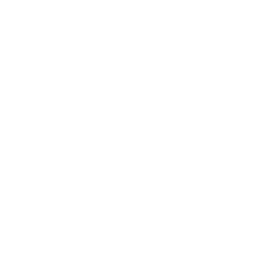
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering von Fertigungs-Fehlermodi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Fertigung / Qualitätsingenieurwesen &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Beispiel entdeckt wiederkehrende **Anlagen-Fehlermodi** aus dem mehrdimensionalen Sensor-Symptomprofil, das bei jedem Ausfallereignis aufgezeichnet wird. Acht standardisierte Symptomvariablen (Vibration, Temperaturdelta, Druckabfall, Stromspitze, Geräusch, Zykluszeitabweichung, Drehmomentvarianz, Ölpartikelzahl) werden mit **hierarchischem Clustering nach Complete-Linkage** (`PROC CLUSTER METHOD=COMPLETE`) geclustert, das kompakte, gut getrennte Gruppen bevorzugt. `PROC TREE` schneidet die Hierarchie anschließend in **sechs Fehlermodi**, und `PROC FREQ` kreuztabelliert diese Modi gegen Anlagentyp und Schicht, um auf systematische Assoziationen zu prüfen.

Der Lauf hier wird auf einer **100-Ereignis-Stichprobe** ausgeführt (die Umgebung begrenzt die Ausgabe auf 100 Beobachtungen). In dieser Stichprobe sind die sechs Modi ungefähr gleich groß (jeweils n = 16-17) und werden primär durch **Temperatur-, Druck- und Vibrations**signaturen statt durch den Anlagentyp getrennt — die Kreuztabellen Modus-nach-Anlage und Modus-nach-Schicht sind bei diesem Stichprobenumfang **nicht** statistisch signifikant (Chi-Quadrat p = 0.15 bzw. p = 0.07). Der Arbeitsablauf skaliert unverändert auf die vollständige Ereignishistorie, wo größere Fallzahlen je Modus diese Assoziationen schärfen würden.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|---------|
| WORK.FAILURES | Symptomprofile von Anlagen-Ausfallereignissen (synthetisch) | 100 |
| WORK.FAILURES_STD | Auf Mittelwert 0, Std 1 standardisierte Symptome (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Merge-Historie nach Complete-Linkage (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Sechs-Modi-Schnitt aus `PROC TREE NCLUSTERS=6` | 100 |

*Diese Umgebung läuft im unlizenzierten Modus und begrenzt die Ausgabe auf 100 Beobachtungen; der synthetische Generator fordert 20,000 Ereignisse an, aber nur die ersten 100 werden behalten. Die nachstehende Analyse gründet vollständig auf dieser 100-Ereignis-Stichprobe.*

---

In [1]:
/* --------------------------------------------------------
   Synthetische Symptomprofile von Ausfallereignissen erzeugen
   20.000 Ausfallereignisse über 50 Anlagen
   -------------------------------------------------------- */
DATEN work.failures;
    AUFRUFEN streaminit(42);
    FELD equip_type_list[4] $20 _temporary_ ('PRESSE' 'FOERDERBAND' 'ROBOTERARM' 'OFEN');
    FELD shift_list[3] $8 _temporary_ ('TAG' 'ABEND' 'NACHT');
    AUSFÜHRUNG event_id = 1 BIS 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Symptomprofil: 8 Sensorwerte zum Ausfallzeitpunkt */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        WENN vibration_level < 0 DANN vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        WENN current_spike < 0 DANN current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        AUSGABE;
    ENDE;
    ENTFERNEN equip_num etype_idx shift_idx;
    format failure_date date9.;
    BEZEICHNUNG
        failure_id           = 'Ausfall-ID'
        equipment_id         = 'Anlagen-ID'
        equipment_type       = 'Anlagentyp'
        shift                = 'Schicht'
        failure_date         = 'Ausfalldatum'
        vibration_level      = 'Vibrationspegel'
        temperature_delta    = 'Temperaturdifferenz (°C)'
        pressure_drop        = 'Druckabfall'
        current_spike        = 'Stromspitze'
        noise_db             = 'Geräuschpegel (dB)'
        cycle_time_deviation = 'Zykluszeitabweichung'
        torque_variance      = 'Drehmomentvarianz'
        oil_particle_count   = 'Ölpartikelzahl'
        downtime_minutes     = 'Ausfallzeit (Min.)';
AUSFÜHREN;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.51 seconds
  cpu   6.51 seconds


---

In [2]:
/* --------------------------------------------------------
   Basis-Symptomverteilungen nach Anlagentyp
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.failures n mean std MAX;
    KLASSE equipment_type;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    TITEL 'Ausfall-Symptomprofile nach Anlagentyp';
AUSFÜHREN;

                                         Ausfall-Symptomprofile nach Anlagentyp                                         

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Vibrationspegel

        Anlagentyp           N Obs           Mean        Std Dev        Maximum
        -----------------------------------------------------------------------
        FOERDERBAND             19      3.8089474      1.8662437      9.0400000
        OFEN                    26      4.3638462      2.0371177     10.1400000
        PRESSE                  30      4.6273333      2.1610740      9.9400000
        ROBOTERARM              25      3.5320000      1.9296070      6.7900000
        -----------------------------------------------------------------------

                            Analysis Variable : temperature_delta Temperaturdifferenz (°C)

        Anlagentyp           N Obs           Mean        Std Dev   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                         Ausfall-Symptomprofile nach Anlagentyp                                         




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


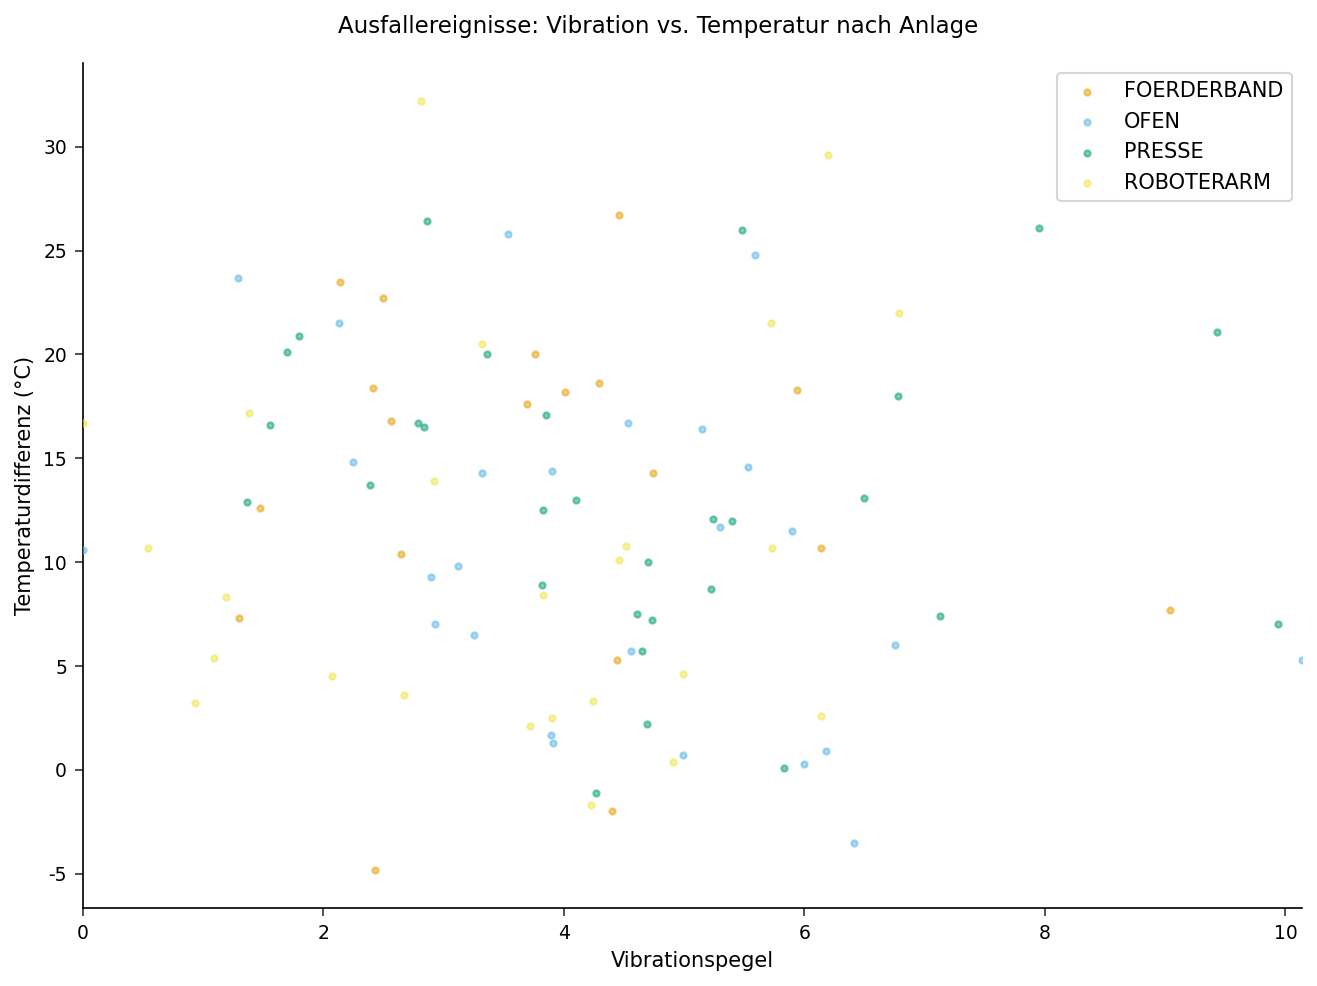

In [3]:
/* --------------------------------------------------------
   Vibration vs. Temperaturdifferenz nach Anlagentyp
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS BEZEICHNUNG='Vibrationspegel';
    YAXIS BEZEICHNUNG='Temperaturdifferenz (°C)';
    TITEL 'Ausfallereignisse: Vibration vs. Temperatur nach Anlage';
AUSFÜHREN;

---

In [4]:
/* --------------------------------------------------------
   Symptomvariablen für das Clustering standardisieren
   -------------------------------------------------------- */
PROZEDUR STANDARD DATEN=work.failures out=work.failures_std
    mean=0 std=1;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
AUSFÜHREN;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                         Ausfall-Symptomprofile nach Anlagentyp                                         

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


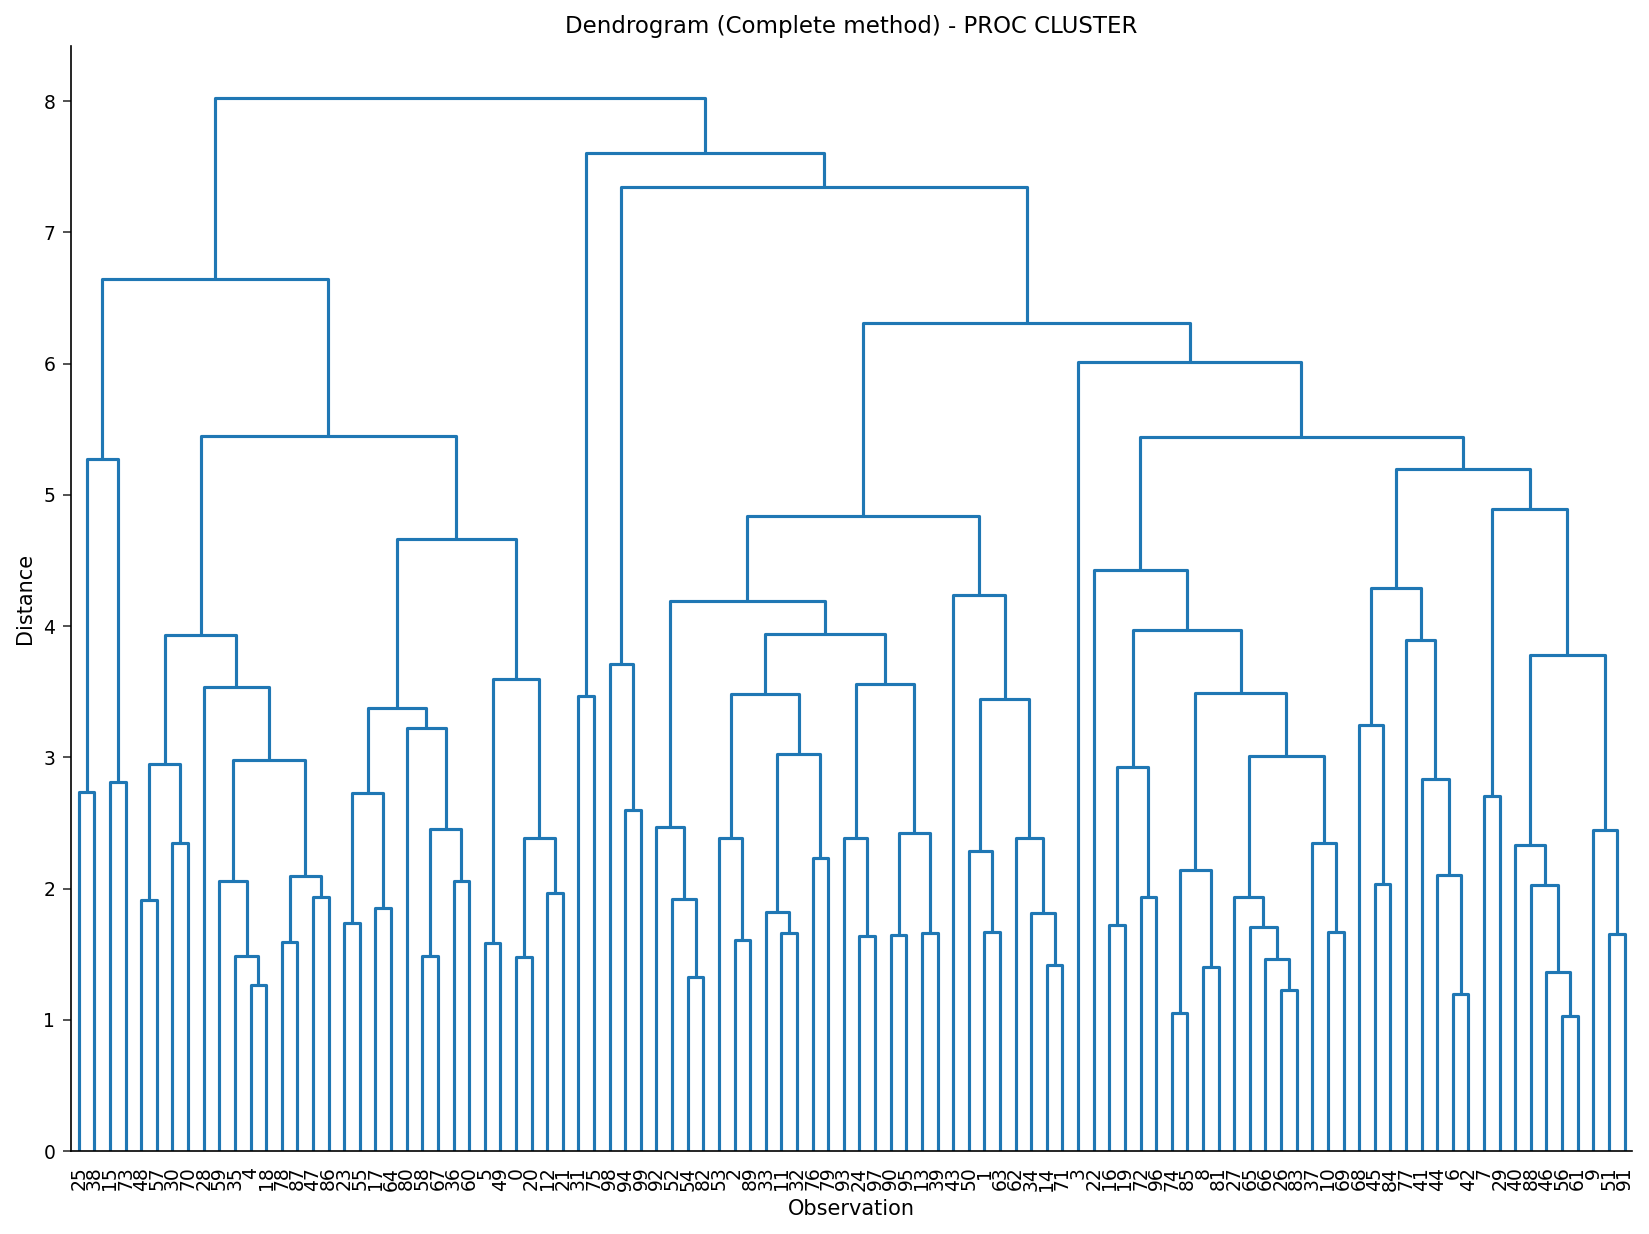

In [5]:
/* --------------------------------------------------------
   Complete-Linkage-Clustering mit TRIM= zur Ausreißer-
   entfernung. TRIM=5 entfernt die 5 % am weitesten
   entfernten Beobachtungen vor der Clusterbildung.
   -------------------------------------------------------- */
PROZEDUR CLUSTER DATEN=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo DRUCKEN=20 trim=5;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
AUSFÜHREN;

In [6]:
/* --------------------------------------------------------
   Die Complete-Linkage-Hierarchie mit PROC TREE
   (NCLUSTERS=6) in sechs Fehlermodi schneiden. Sechs ist
   als praktische, interpretierbare Granularität für die
   Triage gewählt; das Dendrogramm oben zeigt die Merge-
   Struktur, die dieser Schnitt partitioniert.
   -------------------------------------------------------- */
PROZEDUR TREE DATEN=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
AUSFÜHREN;

                                         Ausfall-Symptomprofile nach Anlagentyp                                         




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Zuordnungen zusammenführen und Fehlermodi profilieren
   -------------------------------------------------------- */
DATEN work.failures_classified;
    ZUSAMMENFÜHREN work.failures
          work.failure_mode_assignments(UMBENENNEN=(CLUSTER=failure_mode));
    NACH failure_id;
    BEZEICHNUNG failure_mode = 'Fehlermodus';
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.failures_classified n mean std;
    KLASSE failure_mode;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    TITEL 'Symptomprofile der Fehlermodi (k=6)';
AUSFÜHREN;

                                          Symptomprofile der Fehlermodi (k=6)                                           

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Vibrationspegel

        Fehlermodus          N Obs           Mean        Std Dev
        --------------------------------------------------------
        1                       17      4.3470588      2.6168582
        2                       17      4.2552941      2.2610427
        3                       17      3.6870588      1.8669720
        4                       17      4.0500000      2.0351843
        5                       16      3.4793750      1.4636870
        6                       16      4.9693750      1.6907177
        --------------------------------------------------------

                            Analysis Variable : temperature_delta Temperaturdifferenz (°C)

        Fehlermodus          N Obs        


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                   Verteilung der Fehlermodi nach Anlage und Schicht                                    

                                                   The FREQ Procedure

Table of Fehlermodus by Anlagentyp

Fehlermodus |FOERDERBAND |       OFEN |     PRESSE | ROBOTERARM |       Total
------------+------------+------------+------------+------------+------------
1           |          4 |          5 |          7 |          1 |          17
------------+------------+------------+------------+------------+------------
2           |          3 |          5 |          2 |          7 |          17
------------+------------+------------+------------+------------+------------
3           |          6 |          5 |          2 |          4 |          17
------------+------------+------------+------------+------------+------------
4           |          1 |          5 |          7 |          4 |          17
------------+------------+------------+------------+------------+----


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


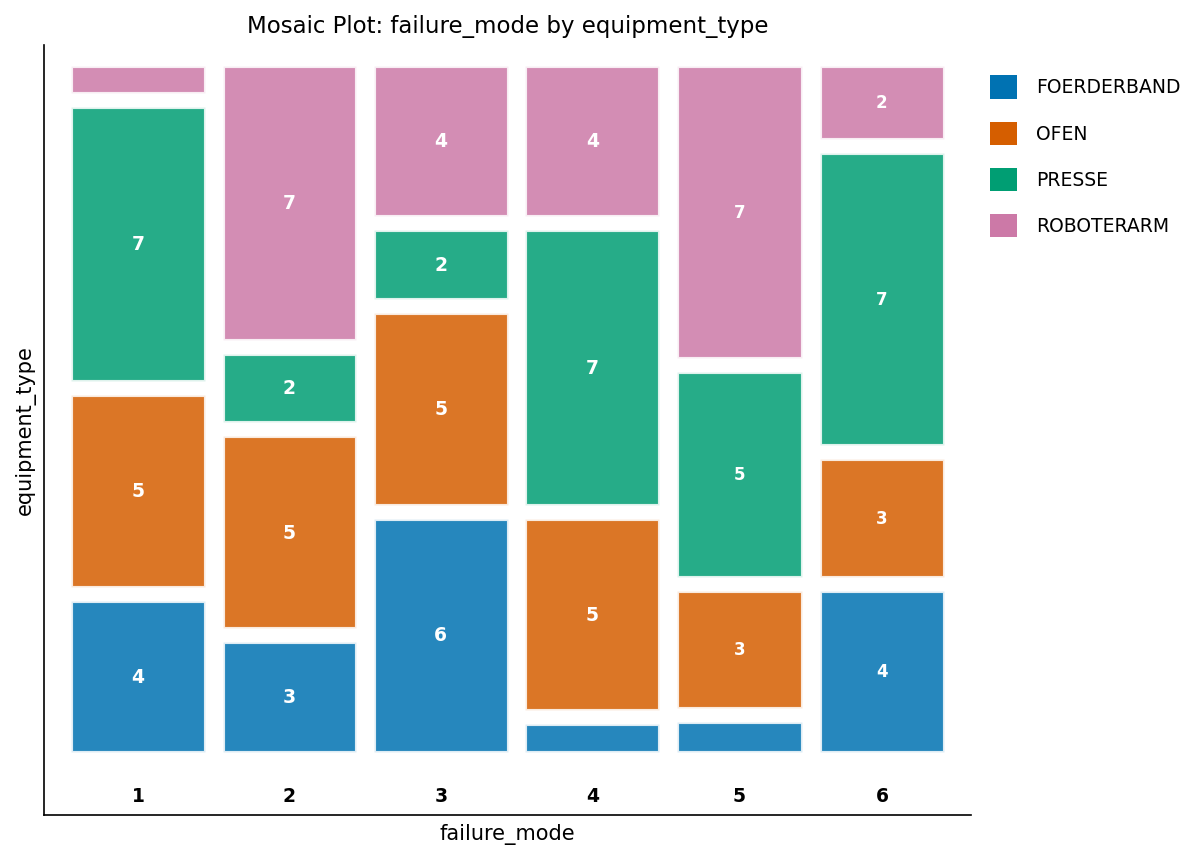

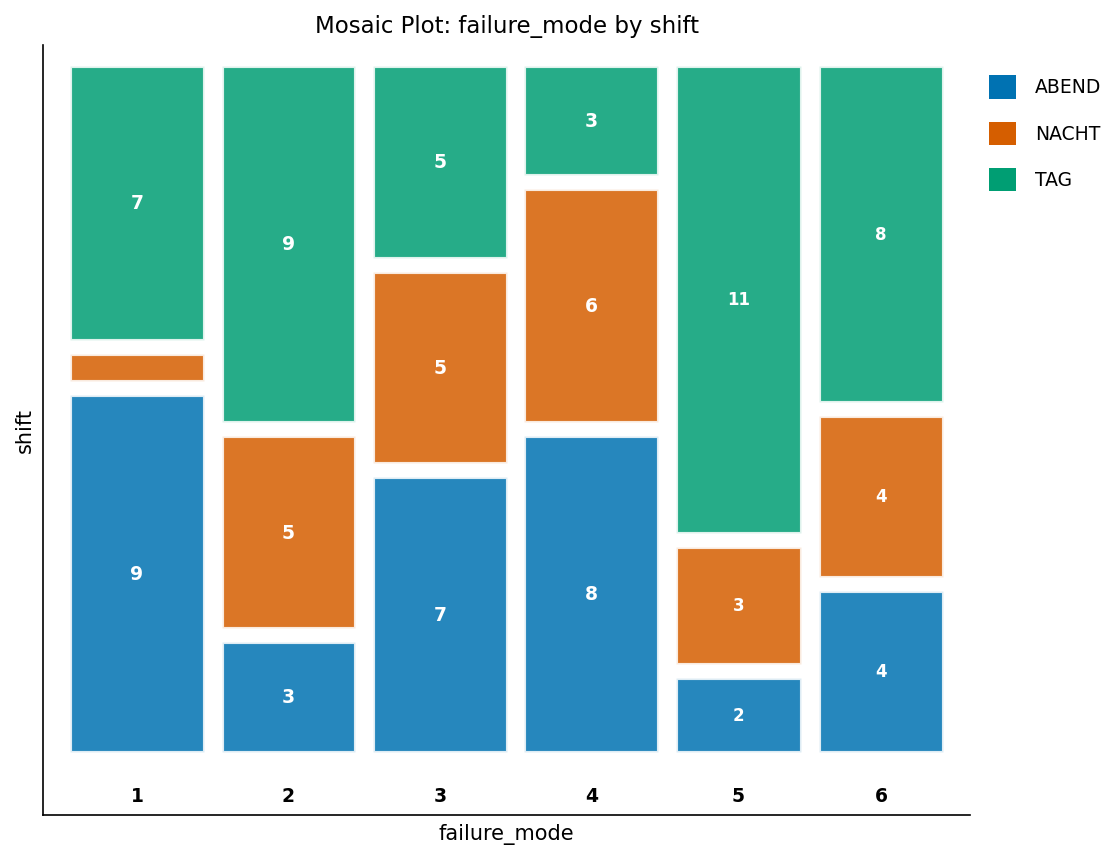

In [8]:
/* --------------------------------------------------------
   Fehlermodi nach Anlagentyp und Schicht kreuztabellieren,
   um systematische Muster zu erkennen
   -------------------------------------------------------- */
PROZEDUR HÄUFIGKEITEN DATEN=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    TITEL 'Verteilung der Fehlermodi nach Anlage und Schicht';
AUSFÜHREN;

---

### Interpretation

Das Complete-Linkage-Clustering der 100 standardisierten Ausfallereignisse ergibt **sechs Fehlermodi** von nahezu gleicher Größe (n = 17, 17, 17, 17, 16, 16). Die Modi werden durch ihre Symptomsignaturen im `PROC MEANS`-Profil oben unterschieden:

- **Modus 6** trägt die stärkste mechanische Belastungssignatur: höchste mittlere Vibration (4.97), höchster Druckabfall (7.51) und höchste Stromspitze (1.61) — aber die **niedrigste** Drehmomentvarianz (1.28).
- **Modus 3** ist der thermische Modus: höchstes Temperaturdelta (16.3 C) bei niedrigstem mittlerem Geräusch (73.0 dB).
- **Modus 2** hat mit großem Abstand die **längste Ausfallzeit** (Mittelwert 85.6 Minuten gegenüber 31-52 bei den anderen Modi) und erhöhte Drehmomentvarianz (3.57), was auf Ereignisse hinweist, deren Behebung kostspieliger ist.
- **Modus 4** ist der mildeste: niedrigste Ausfallzeit (31.4 Minuten) sowie unterdurchschnittlicher Druckabfall und Ölpartikelzahl.
- **Modi 1 und 5** sind Gruppen mit gemischten Symptomen ohne einen einzelnen dominanten Treiber.

Die `PROC FREQ`-Kreuztabellen prüfen, ob sich diese Modi in bestimmten Anlagen oder Schichten konzentrieren. Bei diesem Stichprobenumfang tun sie das **nicht**: Modus-nach-Anlagentyp ergibt Chi-Quadrat = 20.48 (15 df, p = 0.154, Cramérs V = 0.26) und Modus-nach-Schicht ergibt Chi-Quadrat = 17.13 (10 df, p = 0.072, Cramérs V = 0.29) — beide über der Schwelle von 0.05, und über 80% der Zellen haben erwartete Häufigkeiten unter 5, sodass das Chi-Quadrat selbst nur suggestiv ist. Die sichtbaren Tendenzen (Modus 6 neigt zu PRESSE, Modus 5 zur Tagschicht) sind hier deskriptiv, nicht signifikant.

**Fazit:** Complete-Linkage auf standardisierten Symptomprofilen erzeugt eine interpretierbare Sechs-Modi-Taxonomie, die an Temperatur, Druck und Ausfallzeit ausgerichtet ist. Um zu bestätigen, ob Modi bestimmten Anlagen oder Schichten zuzuordnen sind — die handlungsrelevante Ursachenfrage —, benötigt die Analyse die vollständige Ereignishistorie statt dieser 100-Ereignis-Stichprobe, in der die Kreuztabellen unterpowert bleiben.

---

In [9]:
/* --------------------------------------------------------
   Fehlerklassifikationen für die CMMS-Integration exportieren
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>